## **Setup & Data Loading**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import importlib
import os

plt.style.use('fivethirtyeight')
sns.set_palette("viridis")

In [2]:
sys.path.append(os.path.abspath("../"))

In [30]:
import src.metrics

importlib.reload(src.metrics)

from src.metrics import calculate_psi, calculate_csi, plot_psi_distribution, plot_csi_report

In [7]:
TRAIN_SCORED_PATH = '../data/outputs/train_scored_final.csv'
TEST_SCORED_PATH = '../data/outputs/test_scored_final.csv'

train_scored = pd.read_csv(TRAIN_SCORED_PATH)
test_scored = pd.read_csv(TEST_SCORED_PATH)

train_scored.head()

,EXT_SOURCE_2,PREV_INS_AMT_PAYMENT_MIN_MEAN,ORGANIZATION_TYPE,DAYS_BIRTH,BURO_DAYS_CREDIT_ENDDATE_MEAN,PREV_LTV_RATIO_MEAN,BURO_DAYS_CREDIT_MIN,OCCUPATION_TYPE,BURO_CREDIT_ACTIVE_Active_SUM,PREV_INS_AMT_INSTALMENT_MAX_MAX,...,PREV_SELLERPLACE_AREA_MIN,PREV_INS_AMT_INSTALMENT_SUM_MIN,PREV_INS_INS_DBD_SUM_MAX,APP_DTI_RATIO,PREV_INS_INS_DBD_SUM_MIN,PREV_POS_POS_STAT_Active_SUM_MAX,PREV_POS_POS_STAT_Completed_MEAN_MAX,PREV_POS_POS_STAT_Signed_MEAN_MEAN,SCORE,TARGET
0,-0.093777,0.555230,-0.320678,0.033490,-0.195008,-0.092701,-0.213506,-0.178586,0.195528,-0.143020,...,-0.076063,0.090248,0.059321,-0.049124,-0.083980,-0.119426,0.040310,-0.004809,557,0
1,-0.093777,-0.105439,0.008933,-0.279012,-0.223102,0.130345,0.237334,0.349364,0.195528,-0.143020,...,-0.076063,-0.004106,0.059321,-0.045091,0.024701,-0.003566,0.127149,-0.004809,595,0
2,-0.391674,0.174956,-0.128672,0.025137,-0.223102,0.058869,0.237334,0.218789,-0.056591,-0.027946,...,-0.076063,0.015001,0.017113,-0.044853,0.129778,0.090203,-0.194722,-0.004809,553,0
3,0.896714,0.033862,0.665224,-0.291451,0.000000,0.130345,0.000000,-0.249752,0.000000,-0.152945,...,-0.076063,0.015001,-0.109792,-0.044853,-0.083980,-0.061086,-0.011586,-0.004809,565,0
4,0.577858,-0.105439,-0.128672,-0.291451,0.283136,-0.092701,0.237334,0.218789,0.195528,-0.216152,...,0.387239,-0.040562,-0.109792,-0.045091,0.214737,-0.119426,0.040310,-0.004809,586,0


## **Global Population Stability Index (PSI) Calculation**

In [12]:
expected_scores = train_scored['SCORE']
actual_scores = test_scored['SCORE']

psi_total, psi_details = calculate_psi(expected_scores, actual_scores, buckets=10)

print(f"TOTAL POPULATION STABILITY INDEX (PSI): {psi_total:.4f}\n")

display(psi_details.style.bar(subset=['PSI_Contribution'], color='#e74c3c'))

TOTAL POPULATION STABILITY INDEX (PSI): 0.0002



,Bucket,Expected_%,Actual_%,PSI_Contribution
0,"(-inf, 531.0]",10.215037,9.971383,0.000059
1,"(531.0, 545.0]",10.681309,10.685716,0.000000
2,"(545.0, 554.0]",9.650603,9.559477,0.000009
3,"(554.0, 562.0]",9.954293,9.955124,0.000000
4,"(562.0, 570.0]",10.386822,10.509029,0.000014
5,"(570.0, 577.0]",9.187398,9.100960,0.000008
6,"(577.0, 586.0]",10.905242,11.168079,0.000063
7,"(586.0, 595.0]",9.147520,9.200685,0.000003
8,"(595.0, 609.0]",10.420565,10.419060,0.000000
9,"(609.0, inf]",9.451210,9.430485,0.000000


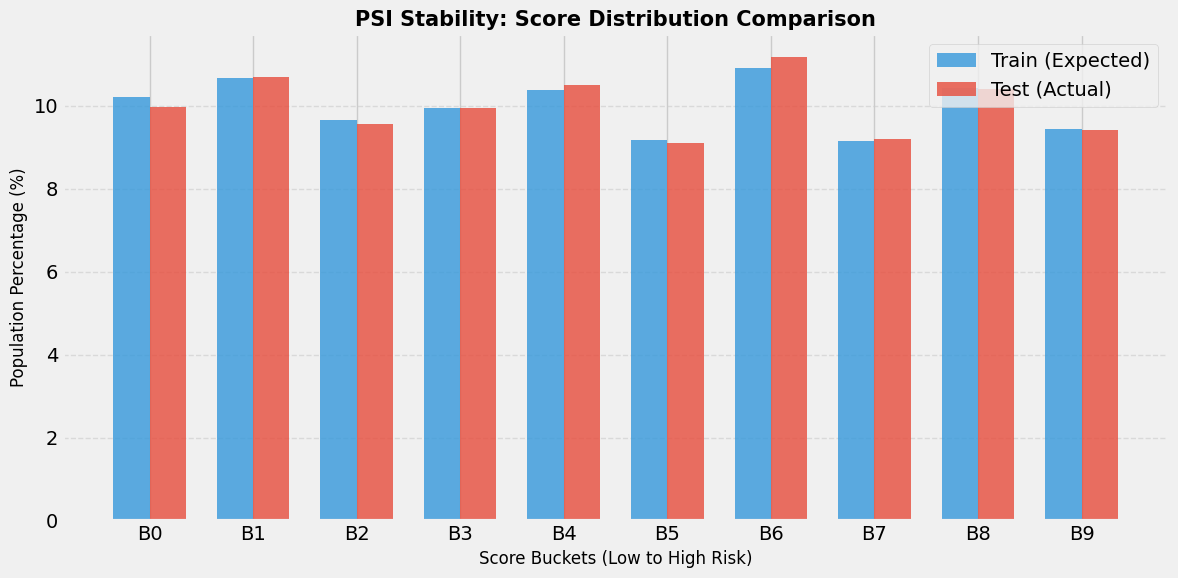

In [11]:
plot_psi_distribution(psi_details)

## **Characteristic Stability Index (CSI) - Feature Level Analysis**

In [19]:
features_to_check = [col for col in train_scored.columns if col not in ['TARGET', 'SCORE', 'SK_ID_CURR']]

print(f"Feature Count: {len(features_to_check)}")

csi_results = calculate_csi(train_scored, test_scored, features_to_check)

print("\nTop 5 Most 'Drifting' Features:")
print(csi_results.head(5))

Feature Count: 39

Top 5 Most 'Drifting' Features:
PREV_ESTIMATED_TERM_MEAN           0.000615
EXT_SOURCE_2                       0.000322
DAYS_LAST_PHONE_CHANGE             0.000318
PREV_INS_AMT_INSTALMENT_MAX_MAX    0.000285
DAYS_REGISTRATION                  0.000280
dtype: float64


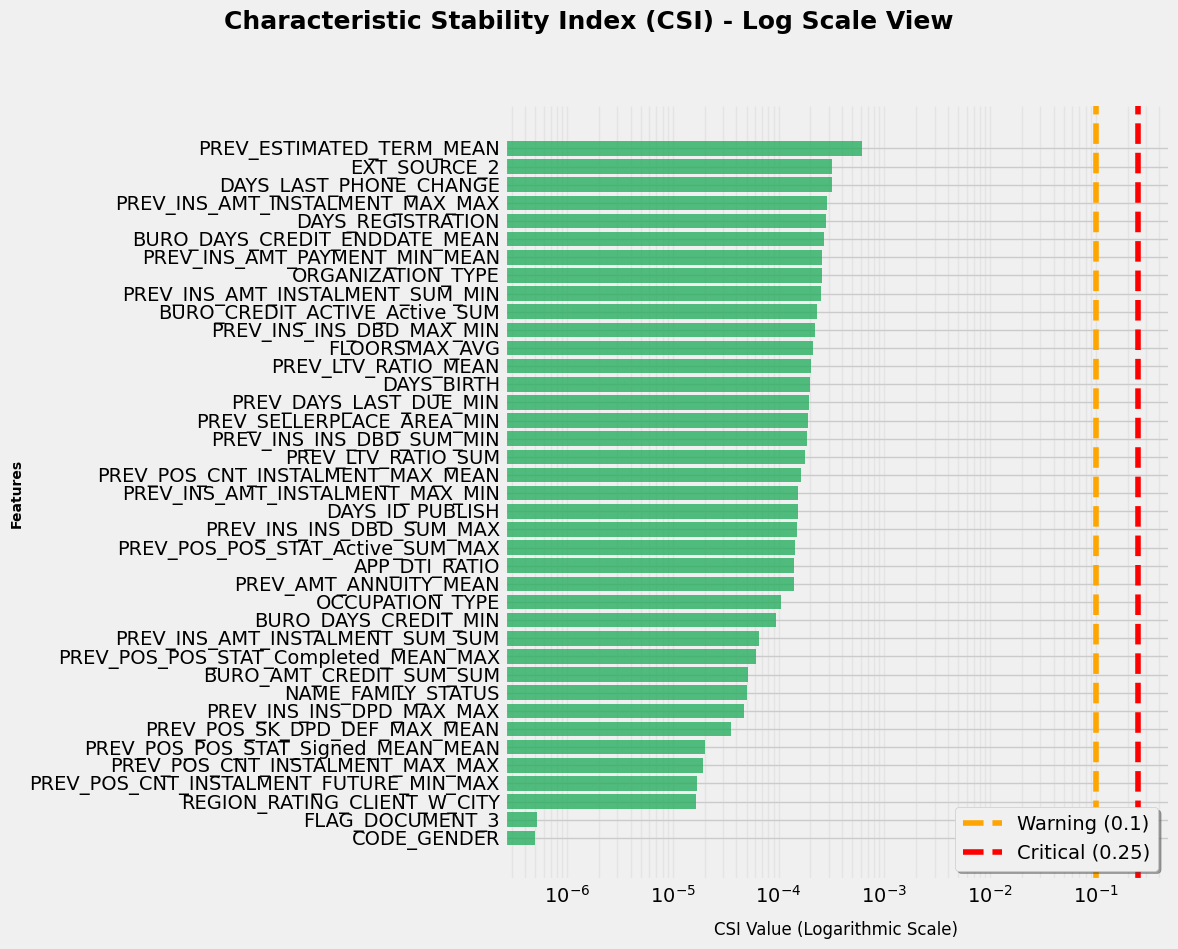

In [31]:
plot_csi_report(csi_results, use_log=True)